In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import os
from collections import defaultdict
from sklearn.metrics.pairwise import haversine_distances
from enum import Enum
from tqdm import tqdm

from data_visualisation import *

# Data Handling and Preprocessing

In [8]:
def import_data(data : str) -> pd.DataFrame:
    if not os.path.exists(data):
        print("Error: file does not exist.")
        return None
    df = pd.read_csv(data)
    return df

In [9]:
def preprocess_data (df: pd.DataFrame, min_population : float =1e5) -> pd.DataFrame:
    df = df.dropna()
    df = df[df['country'] == 'India']
    df = df[df['population'] >= min_population]
    df = df[df['lng'].between(65, 100) & df['lat'].between(5, 40)]
    df = df.drop_duplicates(subset=['city'])
    df = df[['city', 'population', 'country', 'lat', 'lng']].copy()
    df = df.reset_index(drop=True)
    df.insert(0, 'city_id', range(len(df)))
    
    return df

In [10]:
data_path = "data/indiacities.csv"

df = import_data(data_path)
df = preprocess_data(df, 1e5)
df.to_csv("data/cities_data.csv", index = False)

# Cost Calculations

### Constants

In [11]:
class TransportMode(Enum):
    ROAD = "road"
    RAIL = "rail"
    AIR = "air"
    
## Cost of travel when transporting freight by different modes (INR/tonne-km)
TRAVEL_COSTS_TONNE_KM = {
    TransportMode.ROAD: 3.6,
    TransportMode.RAIL: 1.6,
    TransportMode.AIR: 18,
}

## CO2 emissions when transporting freight by different modes (gm CO2/tonne-km)
CO2_EMISSIONS_TONNE_KM = {
    TransportMode.ROAD: 101,
    TransportMode.RAIL: 11.5,
    TransportMode.AIR: 610,
}

TRAVEL_SPEEDS = {
    TransportMode.ROAD: 30,
    TransportMode.RAIL: 35,
    TransportMode.AIR: 450,
}

In [12]:
COST_OF_CARBON_KG = 4.42    # Median carbon shadow price in major corporations $49/tonne = INR 4.42/kg CO2
CONSUMPTION_RATE = 2.78   # Average parcels per person
AVG_WEIGHT_PER_UNIT_KG = 1.5 # Typical Amazon parcel avg weight
TIME_VALUE_KG_HOUR = 2.0
AOV_INDIA = 9600.0
CARRYING_RATE = 0.20
CARRYING_COST_PARCEL_HOUR = AOV_INDIA*CARRYING_RATE/8760
TIME_VALUE_KG_HOUR = CARRYING_COST_PARCEL_HOUR*AVG_WEIGHT_PER_UNIT_KG
SHIPMENT_WEIGHT_PER_PERSON = CONSUMPTION_RATE*AVG_WEIGHT_PER_UNIT_KG
WAREHOUSE_LAND_AREA = 2.5e5
LAND_RENT_SQFT_YEAR = 24*12
OPEX_RATIO = 0.5
WAREHOUSE_COST = WAREHOUSE_LAND_AREA*LAND_RENT_SQFT_YEAR*(1+OPEX_RATIO)

### Cost Functions

In [13]:
def get_distance_matrix(df: pd.DataFrame) -> pd.DataFrame:

    lat = df["lat"].to_numpy()
    lng = df["lng"].to_numpy()
    cities = df["city"].to_numpy()
    
    coords = np.column_stack([np.radians(lat), np.radians(lng)])
    d_mat = haversine_distances(coords)
    
    # Convert radians to km (Earth radius = 6371 km)
    d_mat = d_mat * 6371

    return pd.DataFrame(d_mat, index=cities, columns=cities)

In [247]:
def calc_fuel_cost(distance_km: float, 
                   mode: TransportMode, 
                   weight_kg: float = SHIPMENT_WEIGHT_PER_PERSON, 
                   travel_costs_tonne_km: dict = TRAVEL_COSTS_TONNE_KM) -> float:
    
    tonnes = weight_kg/1000
    linear_cost = travel_costs_tonne_km[mode]
    if mode == TransportMode.AIR:
        a_takeoff = 10000.0
        k_takeoff = 0.005
        
        return (SHIPMENT_WEIGHT_PER_PERSON/1000) * (a_takeoff * (1 - np.exp(-k_takeoff * distance_km)) + linear_cost * distance_km) * (1+0.5*(distance_km > 1200))
    else:
        return linear_cost * (SHIPMENT_WEIGHT_PER_PERSON/1000) * distance_km

In [248]:
def calc_carbon_cost(distance_km: float, 
                     mode: TransportMode, 
                     weight_kg: float, 
                     emissions_tonne_km: dict = CO2_EMISSIONS_TONNE_KM, 
                     cost_of_carbon_per_kg: float = COST_OF_CARBON_KG) -> float:
    
    total_emissions_kg = (emissions_tonne_km[mode] * (SHIPMENT_WEIGHT_PER_PERSON/1000) * distance_km) / 1000.0
    return total_emissions_kg * cost_of_carbon_per_kg

In [249]:
def calc_time_penalty(distance_km: float, 
                      mode: TransportMode, 
                      weight_kg: float, 
                      time_value_kg_hour: float = TIME_VALUE_KG_HOUR) -> float:
    
    # Avg block speeds
    speeds = {
        TransportMode.AIR: 532.0,
        TransportMode.RAIL: 25.0,
        TransportMode.ROAD: 30.0,
    }
    
    travel_hours = distance_km / speeds[mode]
    
    # 1. Pipeline Inventory Cost (Capital tied up in transit)
    holding_cost = travel_hours * time_value_kg_hour * SHIPMENT_WEIGHT_PER_PERSON
    
    # 2. Service Penalty (Modeling lost sales/customer dissatisfaction)
    # service_penalty = 0.0
    # if travel_hours > 48:
    #     service_penalty = (travel_hours-48)*(time_value_kg_hour*100)*weight_kg
        
    return holding_cost 
    # + service_penalty

In [17]:
def get_transport_mode_cost(distance_km: float, 
                            mode: TransportMode, 
                            shipment_weight_kg: float, 
                            cost_weights: dict) -> tuple[float, dict]:
    
    fuel = calc_fuel_cost(distance_km, mode, shipment_weight_kg)
    carbon = calc_carbon_cost(distance_km, mode, shipment_weight_kg)
    time = calc_time_penalty(distance_km, mode, shipment_weight_kg)
    
    cost_components = {
        "fuel": fuel,
        "carbon": carbon,
        "time": time,
        "mode": mode,
    }
    
    # Normalisation
    cost_weights = {k: v/sum(cost_weights.values()) for k,v in cost_weights.items()}
    
    weighted_cost = fuel*cost_weights["fuel"] + carbon*cost_weights["carbon"]+time*cost_weights["time"]
    
    return weighted_cost, cost_components

In [18]:
def get_transport_cost(source: str, 
                       dest: str, 
                       distance_matrix: pd.DataFrame,
                       df: pd.DataFrame,
                       air_df: pd.DataFrame, 
                       rail_df: pd.DataFrame, 
                       cost_weights: dict) -> tuple[float, dict]:

    dest_population = df.loc[df['city'] == dest]['population'].iloc[0]
    shipment_weight_kg = dest_population * SHIPMENT_WEIGHT_PER_PERSON

    
    distance = distance_matrix[source][dest]
    rail_cost = float('inf')
    air_cost = float('inf')
    road_cost = float('inf')
    components = {
        "fuel": float('inf'),
        "carbon": float('inf'),
        "time": float('inf'),
        "mode": 'not known',
    }
    if not (source == "Port Blair" or dest == "Port Blair"):
        road_cost, components = get_transport_mode_cost(distance, TransportMode.ROAD, shipment_weight_kg, cost_weights)

    optimal_cost = road_cost
        
    if source in air_df["city"].values and dest in air_df["city"].values:
        air_cost, comp = get_transport_mode_cost(distance, TransportMode.AIR, shipment_weight_kg, cost_weights)
        if air_cost < optimal_cost:
            optimal_cost = air_cost
            components = comp
    if source in rail_df["city"].values and dest in rail_df["city"].values:
        rail_cost, comp = get_transport_mode_cost(distance, TransportMode.RAIL, shipment_weight_kg, cost_weights)
        if rail_cost < optimal_cost:
            optimal_cost = rail_cost
            components = comp

    return optimal_cost, components

In [291]:
def get_direct_transport_cost_matrix(df: pd.DataFrame,
                         air_df: pd.DataFrame,
                         rail_df: pd.DataFrame,
                         distance_matrix: pd.DataFrame,
                         cost_weights: dict) -> pd.DataFrame:
    cities = df["city"].values
    n = len(cities)
    cost_matrix = np.zeros((n,n))
    city_to_idx = {city: idx for idx, city in enumerate(cities)}

    data = {}
    
    for source in tqdm(cities, desc="Step 2/4: Building transport cost matrix..."):
        row_data = {}
        for dest in cities:
            if source == dest:
                row_data[dest] = (0, {'fuel': 0, 'carbon': 0, 'time': 0, 'mode': 'no transport'})
            else:
                optimal_cost, components = get_transport_cost(
                    source, dest, distance_matrix, df, air_df, rail_df, cost_weights
                )
                row_data[dest] = (optimal_cost, components)
        data[source] = row_data
    
    return pd.DataFrame(data)

In [292]:
def floyd_warshall(
    transport_cost_matrix: pd.DataFrame,
    cities: np.ndarray,
    eps: float = 1e-5
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    dist_dict = {}
    components_dict = {}
    next_node_dict = {}
    hops = {}

    # Initialization
    for i in cities:
        dist_dict[i] = {}
        components_dict[i] = {}
        next_node_dict[i] = {}
        hops[i] = {}

        for j in cities:
            if i == j:
                dist_dict[i][j] = 0.0
                hops[i][j] = 0
                next_node_dict[i][j] = None
                components_dict[i][j] = {
                    'fuel': 0.0,
                    'carbon': 0.0,
                    'time': 0.0,
                    'mode': 'no transport'
                }

            else:
                cost, components = transport_cost_matrix[i][j]
                dist_dict[i][j] = float(cost)
                hops[i][j] = 1
                next_node_dict[i][j] = j
                components_dict[i][j] = components.copy()

    # Floyd Warshall
    for k in tqdm(cities, desc="Step 3/4: Running Floyd Warshall algorithm..."):
        for i in cities:
            if dist_dict[i][k] == float('inf'):
                continue
            for j in cities:
                if dist_dict[k][j] == float('inf'):
                    continue

                new_cost = dist_dict[i][k] + dist_dict[k][j]
                old_cost = dist_dict[i][j]

                new_hops = hops[i][k] + hops[k][j]
                old_hops = hops[i][j]

                if (
                    new_cost < old_cost - eps
                    or (abs(new_cost - old_cost) <= eps and new_hops < old_hops)
                ):
                    dist_dict[i][j] = new_cost
                    hops[i][j] = new_hops
                    next_node_dict[i][j] = next_node_dict[i][k]
                    components_dict[i][j] = {
                        'fuel': components_dict[i][k]['fuel'] + components_dict[k][j]['fuel'],
                        'carbon': components_dict[i][k]['carbon'] + components_dict[k][j]['carbon'],
                        'time': components_dict[i][k]['time'] + components_dict[k][j]['time'],
                        'mode': 'mixed'
                    }

    dist_df = pd.DataFrame(dist_dict)
    components_df = pd.DataFrame(components_dict)
    next_node_df = pd.DataFrame(next_node_dict)

    return dist_df, components_df, next_node_df


### Network Analysis

In [286]:
def analyse_network(df: pd.DataFrame,
                    air_df:pd.DataFrame,
                    rail_df: pd.DataFrame,
                    weights: dict) -> tuple:
    print("Step 1/4: Calculating physical distance matrix...")
    dist_matrix = get_distance_matrix(df)

    direct_cost_matrix = get_direct_transport_cost_matrix(
        df=df,
        air_df=air_df,
        rail_df=rail_df,
        distance_matrix=dist_matrix,
        cost_weights=weights
    )
    cities = df["city"].values
    return floyd_warshall(transport_cost_matrix=direct_cost_matrix, cities=cities)

In [22]:
def assign_fcs(df: pd.DataFrame,
               fc_df: pd.DataFrame,
               transport_costs: pd.DataFrame,
               cost_components: pd.DataFrame) -> pd.DataFrame:

    hub_to_city_costs = transport_costs.loc[:, fc_df['city'].values]
   
    fca = hub_to_city_costs.idxmin(axis = 1).to_frame(name = 'fc')
    # analyze_and_visualize_fc_network(df, fc_df, assign_df, transport_components)
    return fca

In [259]:
def calc_network_cost(df: pd.DataFrame,
                      fc_df: pd.DataFrame,
                      fc_sol: np.ndarray,
                      transport_costs: pd.DataFrame,
                      cost_components: pd.DataFrame,
                      warehouse_costs: float = WAREHOUSE_COST) -> float:
    if np.sum(fc_sol) == 0:
        return float('inf'), None
    fc_cities = pd.DataFrame(fc_df['city'].values[fc_sol == 1], columns = ['city'])
    assigned_fcs = assign_fcs(df, fc_cities, transport_costs, cost_components)
    transport_cost_total = 0
    assigned = assigned_fcs.join(df.set_index('city')['population'], how='left')
    cost_per_person = transport_costs.to_numpy()[
        transport_costs.index.get_indexer(assigned.index),
        transport_costs.columns.get_indexer(assigned['fc'])
    ]
    transport_cost_total = (cost_per_person * assigned['population'].to_numpy()).sum()
    # print(f"Transport cost: {transport_cost_total}")
    fixed_cost = warehouse_costs* np.sum(fc_sol)
    # print(f"Fixed cost: {fixed_cost}")
    cost = transport_cost_total+fixed_cost
    return cost, assigned_fcs

# Genetic Optimization Algorithm

In [24]:
def init_pop(sol_size: int, count: int) -> np.ndarray:
    pop = np.random.binomial(1, 0.5, size=(count, sol_size))
    
    all_zeros = pop.sum(axis=1) == 0
    
    if all_zeros.any():
        zero_row_indices = np.where(all_zeros)[0]
        random_cols = np.random.randint(0, sol_size, size=len(zero_row_indices))
        pop[zero_row_indices, random_cols] = 1

    return pop

In [185]:
def crossover(generation_size: int,
              pop_size: int,
              repro_size: int,
              current_gen: np.ndarray,
              scores: np.ndarray) -> np.ndarray:

    crossover_size = 2*generation_size-repro_size
    crossover_gen = np.zeros((crossover_size, pop_size))
    finite = np.isfinite(scores)
    probabilities = None
    if not np.min(scores[finite]) == np.max(scores[finite]):
        normalized_scores = np.zeros_like(scores, dtype=float)
        normalized_scores[finite] = (
            (np.max(scores[finite]) - scores[finite]) /
            (np.max(scores[finite]) - np.min(scores[finite]))
        )

        probabilities = normalized_scores/np.sum(normalized_scores)
    else:
        probabilities = np.ones_like(scores, dtype = float)*(1/generation_size)
    for i in range(0, crossover_size, 2):
        parent_indices = np.random.choice(generation_size, size = 2, p = probabilities, replace = True)
        p1, p2 = current_gen[parent_indices[0], :], current_gen[parent_indices[1], :]
        point = np.random.randint(1, pop_size)
        child1 = np.concatenate([p1[:point], p2[point:]])
        child2 = np.concatenate([p2[:point], p1[point:]])
        crossover_gen[i, :] = child1[:]
        crossover_gen[i+1,:] = child2[:]
    return crossover_gen

In [140]:
def mutation(generation: np.ndarray,
             mutation_rate_pop: float,
             mutation_rate_bit: float,
            ) -> np.ndarray:
    row_mask = np.random.rand(generation.shape[0]) < mutation_rate_pop
    
    for idx in np.where(row_mask)[0]:
        bit_mask = np.random.rand(generation.shape[1]) < mutation_rate_bit
        generation[idx, bit_mask] = 1 - generation[idx, bit_mask]
    return generation

In [287]:
def genetic_algorithm(generation_size: int,
                      reproduction_rate: float,
                      mutation_rate_pop: float,
                      mutation_rate_bit: float,
                      num_generations: int,
                      df: pd.DataFrame,
                      fc_df: pd.DataFrame):

    # Generation 0
    solution_size = len(fc_df)
    num_repro = (int(generation_size*reproduction_rate)//2)*2
    current_gen = init_pop(sol_size = solution_size, count = generation_size)
    scores = np.array([calc_network_cost(df, fc_df, solution, transport_costs, cost_components)[0] for solution in current_gen])
    indices = np.argsort(scores)
    current_gen = current_gen[indices]

    best_score = float('inf')
    best_sol = []
    min_scores = []
    
    print(f"Running genetic algorithm:")
    print(f"{generation_size} candidates in each generation")
    print(f"Each generation having binary values for {solution_size} FCs")
    
    for gen in tqdm(range(num_generations), desc = "Step  4/4: Genetic algorithm..."):
        new_gen = np.zeros(np.concatenate((current_gen, current_gen)).shape)
        new_gen[:num_repro, :] = current_gen[:num_repro, :]
        new_gen[num_repro:, :] = crossover(generation_size = generation_size, pop_size = solution_size, repro_size = num_repro, current_gen = current_gen, scores = scores)
        scores = np.array([calc_network_cost(df, fc_df, solution, transport_costs, cost_components)[0] for solution in new_gen])
        indices = np.argsort(scores)
        new_gen = new_gen[indices]
        scores = scores[indices]
        
        new_gen = new_gen[:generation_size, :]
        scores = scores[:generation_size]
        new_gen = mutation(new_gen, mutation_rate_pop, mutation_rate_bit)
        current_gen = new_gen
        
        if scores[0] < best_score:
            best_score = scores[0]
            best_sol = new_gen[0]
        min_scores.append(best_score)

    # plot_ga_convergence(min_scores)

    result = {
        "final_pop": best_sol,
        "min_scores": min_scores,
    }
    
    return result
        
        

In [142]:
def plot_ga_convergence(min_scores):
    
    iterations = range(len(min_scores))
    
    plt.figure(figsize=(12, 6))
    
    plt.plot(iterations, min_scores, label='Best Score', marker='.', linewidth=2)
    
    plt.xlabel('Generation', fontsize=12)
    plt.ylabel('Cost', fontsize=12)
    plt.title('Genetic Algorithm Convergence', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('analysis/ga_convergence.png', dpi=300, bbox_inches='tight')
    plt.show()

# Solution Analysis

In [29]:
def get_path(start_city: str,
             end_city:str,
             cost_components: pd.DataFrame,
             next_node: pd.DataFrame) -> np.ndarray:
    path = []
    curr = start_city
    while not curr == end_city:
        path.append({
            'from': curr,
            'to': next_node[curr][end_city],
            'mode': cost_components[curr][next_node[curr][end_city]]['mode'],
            'cost_components': cost_components[curr][next_node[curr][end_city]],
        })
        curr = next_node[curr][end_city]
    return path

In [267]:
def show_dashboard(df: pd.DataFrame, 
                   ga_result: dict, 
                   transport_costs: pd.DataFrame, 
                   cost_components: pd.DataFrame, 
                   next_node: pd.DataFrame, 
                   fc_df: pd.DataFrame, 
                   weights: dict):
    
    best_genome = ga_result['final_pop']
    n_dcs = np.sum(best_genome)
    
    fc_cities = pd.DataFrame(fc_df['city'].values[best_genome == 1], columns=['city'])
    
    fc_assign = assign_fcs(df, fc_cities, transport_costs, cost_components)

    comp_fuel, comp_carbon, comp_time, comp_fixed = 0, 0, 0, n_dcs * WAREHOUSE_COST
    mode_counts = {m: 0 for m in [TransportMode.AIR, TransportMode.RAIL, TransportMode.ROAD]}
    
    network = defaultdict(set)

    for city, row in fc_assign.iterrows():
        fc = row['fc']
        if city == fc:
            continue

        comp_fuel += cost_components[fc][city]['fuel']*df[df['city'] == city]['population'].iloc[0]
        comp_carbon += cost_components[fc][city]['carbon']*df[df['city'] == city]['population'].iloc[0]
        comp_time += cost_components[fc][city]['time']*df[df['city'] == city]['population'].iloc[0]
        
        path = get_path(fc, city, cost_components, next_node)
        
        for hop in path:
            way_det = (hop['from'], hop['to'], hop['mode'])
            network[fc].add(way_det)
            
            if not hop['mode'] == 'mixed': # 'mixed' shouldn't happen on single hop, but keeping safety
                mode_counts[hop['mode']] += 1
                
    total_cost = comp_fuel + comp_carbon + comp_time + comp_fixed
    
    # --- VISUALISATION ---

    ## Summary Setup
    fig = plt.figure(figsize=(20, 14))
    gs = gridspec.GridSpec(4, 2, width_ratios=[1.8, 1], height_ratios=[0.4, 1.2, 1.2, 1.2])
    fig.suptitle("Network Dashboard", fontsize=22, fontweight='bold', y=0.96)

    ## KPI Board
    ax_kpi = fig.add_subplot(gs[0, 1])
    ax_kpi.axis('off')
    kpi_text = (
    f"TOTAL NETWORK PENALTY: {'₹'+f'{(weights["carbon"]*comp_carbon+weights["fuel"]*comp_fuel+weights["time"]*comp_time)/1e7:,.1f}'+' Cr':>23}\n\n"
    f"• Open Hubs: {int(n_dcs):>33}\n"
    f"• Cost of Network: {'₹'+f'{(comp_fixed+comp_fuel)/1e7:,.1f}'+' Cr':>27}\n"
    f"   - Fixed Cost: {'₹'+f'{comp_fixed/1e7:,.1f}'+' Cr':>29}\n"
    f"   - Variable (Transport) Cost: {'₹'+f'{comp_fuel/1e7:,.1f}'+' Cr':>14}\n"
    f"• Carbon Penalty: {'₹'+f'{comp_carbon/1e7:,.1f}'+' Cr':>28}\n"
    f"• Value of Time: {'₹'+f'{comp_time/1e7:,.1f}'+' Cr':>29}"
)
    ax_kpi.text(0.05, 0.5, kpi_text, fontsize=14, va='center', fontfamily='monospace', 
                bbox=dict(boxstyle="round,pad=0.5", fc="aliceblue", ec="navy", alpha=0.8))

    ## Network Map Plot
    ax_map = fig.add_subplot(gs[:, 0])
    
    # 1. Base Layer: Faint background for context
    ax_map.scatter(df['lng'], df['lat'], c='whitesmoke', s=15, alpha=0.5, zorder=0)
    
    unique_fcs = sorted(list(network.keys()))
    if len(unique_fcs) > 0:
        colors = plt.cm.tab20(np.linspace(0, 1, len(unique_fcs)))
        fc_color_map = dict(zip(unique_fcs, colors))
    else:
        fc_color_map = {}
        
    mode_styles = {
        TransportMode.AIR:  {'ls': '-',  'alpha': 0.6, 'lw': 1.0, 'curve': True},
        TransportMode.RAIL: {'ls': '--', 'alpha': 0.5, 'lw': 0.8, 'curve': False},
        TransportMode.ROAD: {'ls': ':',  'alpha': 0.4, 'lw': 0.5, 'curve': False}
    }

    # 3. Plot Cities (Colored by Assigned FC)
    for fc_name in unique_fcs:
        territory_cities = fc_assign[fc_assign['fc'] == fc_name].index
        territory_df = df[df['city'].isin(territory_cities)]
        
        c_color = fc_color_map.get(fc_name, 'grey')
        
        ax_map.scatter(territory_df['lng'], territory_df['lat'], 
                       c=[c_color], s=20, alpha=0.8, zorder=1)

    # 4. Plot Paths (Colored by FC Network)
    for fc_name, segments in network.items():
        base_color = fc_color_map.get(fc_name, 'grey')
        
        for (u, v, mode) in segments:
            p1 = (df[df['city'] == u]['lng'].iloc[0], df[df['city'] == u]['lat'].iloc[0])
            p2 = (df[df['city'] == v]['lng'].iloc[0], df[df['city'] == v]['lat'].iloc[0])
            
            style = mode_styles.get(mode, {'ls':'-', 'alpha':0.1, 'lw':0.5, 'curve':False})
            
            if style['curve']:
                arrow = patches.FancyArrowPatch(
                    p1, p2, arrowstyle='-', color=base_color, 
                    connectionstyle="arc3,rad=0.20", alpha=style['alpha'], 
                    linewidth=style['lw'], linestyle=style['ls'], zorder=2
                )
                ax_map.add_patch(arrow)
            else:
                ax_map.plot([p1[0], p2[0]], [p1[1], p2[1]], 
                            c=base_color, alpha=style['alpha'], 
                            linewidth=style['lw'], linestyle=style['ls'], zorder=2)

    # 5. Plot FC Stars (Colored by Territory)
    for fc_name in unique_fcs:
        c_color = fc_color_map.get(fc_name, 'gold')
        
        fc_row = df[df['city'] == fc_name]
        if not fc_row.empty:
            ax_map.scatter(fc_row['lng'].iloc[0], fc_row['lat'].iloc[0], 
                           c=[c_color], s=300, marker='*', edgecolors='black', zorder=3)
            ax_map.text(fc_row['lng'].iloc[0], fc_row['lat'].iloc[0]+0.25, fc_name, 
                        fontsize=9, fontweight='bold', color='black', zorder=4)

    total_links = sum(len(segs) for segs in network.values())
    ax_map.set_title(f"Fulfillment Center Network | {total_links} Active Links", fontsize=15)
    ax_map.set_xlabel("Longitude")
    ax_map.set_ylabel("Latitude")
    ax_map.grid(True, alpha=0.15)

    legend_elements = [
        Line2D([0], [0], color='black', lw=1.5, linestyle='-', label='Air (Curved)'),
        Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='Rail (Dashed)'),
        Line2D([0], [0], color='black', lw=1.5, linestyle=':', label='Road (Dotted)'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markersize=15, markeredgecolor='black', label='Hub Location')
    ]
    ax_map.legend(handles=legend_elements, loc='lower right')

    # --- Analytics Panels ---
    
    # Cost Breakdown
    ax_cost = fig.add_subplot(gs[1, 1])
    c_vals = [comp_fixed, comp_fuel, comp_carbon, comp_time]
    c_labs = ['Fixed', 'Fuel', 'Carbon', 'Time']
    colors = ['#2c3e50', '#e67e22', '#27ae60', '#c0392b']
    
    ax_cost.barh(np.arange(4), c_vals, color=colors, alpha=0.8)
    ax_cost.set_yticks(np.arange(4))
    ax_cost.set_yticklabels(c_labs)
    ax_cost.set_title('Cost Breakdown', fontsize=12, fontweight='bold')
    
    # Mode Split
    ax_mode = fig.add_subplot(gs[2, 1])
    m_vals = [mode_counts.get(TransportMode.AIR, 0), 
              mode_counts.get(TransportMode.RAIL, 0), 
              mode_counts.get(TransportMode.ROAD, 0)]
    
    if sum(m_vals) > 0:
        ax_mode.pie(m_vals, labels=['Air', 'Rail', 'Road'], autopct='%1.1f%%', 
                    colors=['red', 'blue', 'grey'], startangle=90, explode=(0.05, 0, 0))
        ax_mode.add_artist(plt.Circle((0,0),0.70,fc='white'))
    ax_mode.set_title("Active Link Mode Mix", fontsize=12, fontweight='bold')

    ax_conv = fig.add_subplot(gs[3, 1])
    min_scores = ga_result['min_scores']
    
    iterations = range(len(min_scores))
    
    ax_conv.plot(iterations, min_scores, label='Best Score', marker='.', linewidth=2)
    
    ax_conv.set_xlabel('Generation', fontsize=12)
    ax_conv.set_ylabel('Cost', fontsize=12)
    ax_conv.set_title('Genetic Algorithm Convergence', fontsize=14)
    ax_conv.legend()
    ax_conv.grid(True, alpha=0.3)
    # ax_conv.savefig('analysis/ga_convergence.png', dpi=300, bbox_inches='tight')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Main Run

### Data Setup

In [31]:
total_data_path = "data/cities_data.csv"
airway_data_path = "data/airway_nodes.csv"
railway_data_path = "data/railway_nodes.csv"
# fc_data_path = "data/fc_candidates.csv"

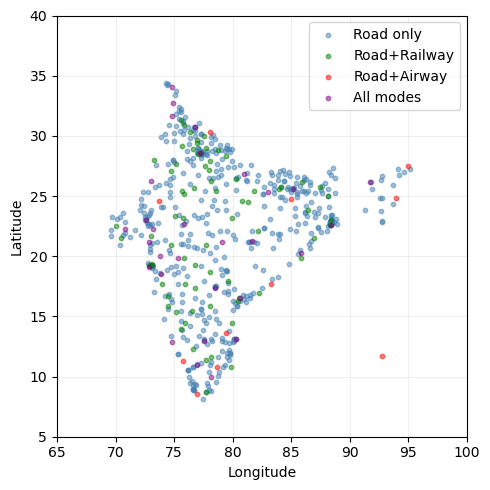

In [32]:
df = import_data(total_data_path)
air_df = import_data(airway_data_path)
rail_df = import_data(railway_data_path)
# fc_df = import_data(fc_data_path)
fc_df = pd.DataFrame(df['city'])
# df.info()
# air_df.info()
# rail_df.info()
# fc_df.info()
plot_cities(df, air_df, rail_df)

In [40]:
weights = {
    "fuel": 0,
    "carbon": 0,
    "time": 1,
}

### Cost Analysis

In [ ]:
transport_costs, cost_components, next_node = analyse_network(df, air_df, rail_df, weights)

### Genetic Algorithm

In [273]:
generation_size = 200
reproduction_rate = 0.01
mutation_rate_pop = 1.0
mutation_rate_bit = 0.005
num_generations = 500

In [ ]:
ga = genetic_algorithm(generation_size = generation_size, 
                       reproduction_rate = reproduction_rate, 
                       mutation_rate_pop = mutation_rate_pop,
                       mutation_rate_bit = mutation_rate_bit,
                       num_generations = num_generations,
                       df = df,
                       fc_df = fc_df)

In [ ]:
show_dashboard(df, ga, transport_costs, cost_components, next_node, fc_df, weights)

Step 1/4: Calculating physical distance matrix...


Step 3/4: Running Floyd Warshall algorithm...: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 602/602 [00:35<00:00, 17.01it/s]


Running genetic algorithm:
200 candidates in each generation
Each generation having binary values for 602 FCs


Step  4/4: Genetic algorithm...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [02:10<00:00,  3.84it/s]


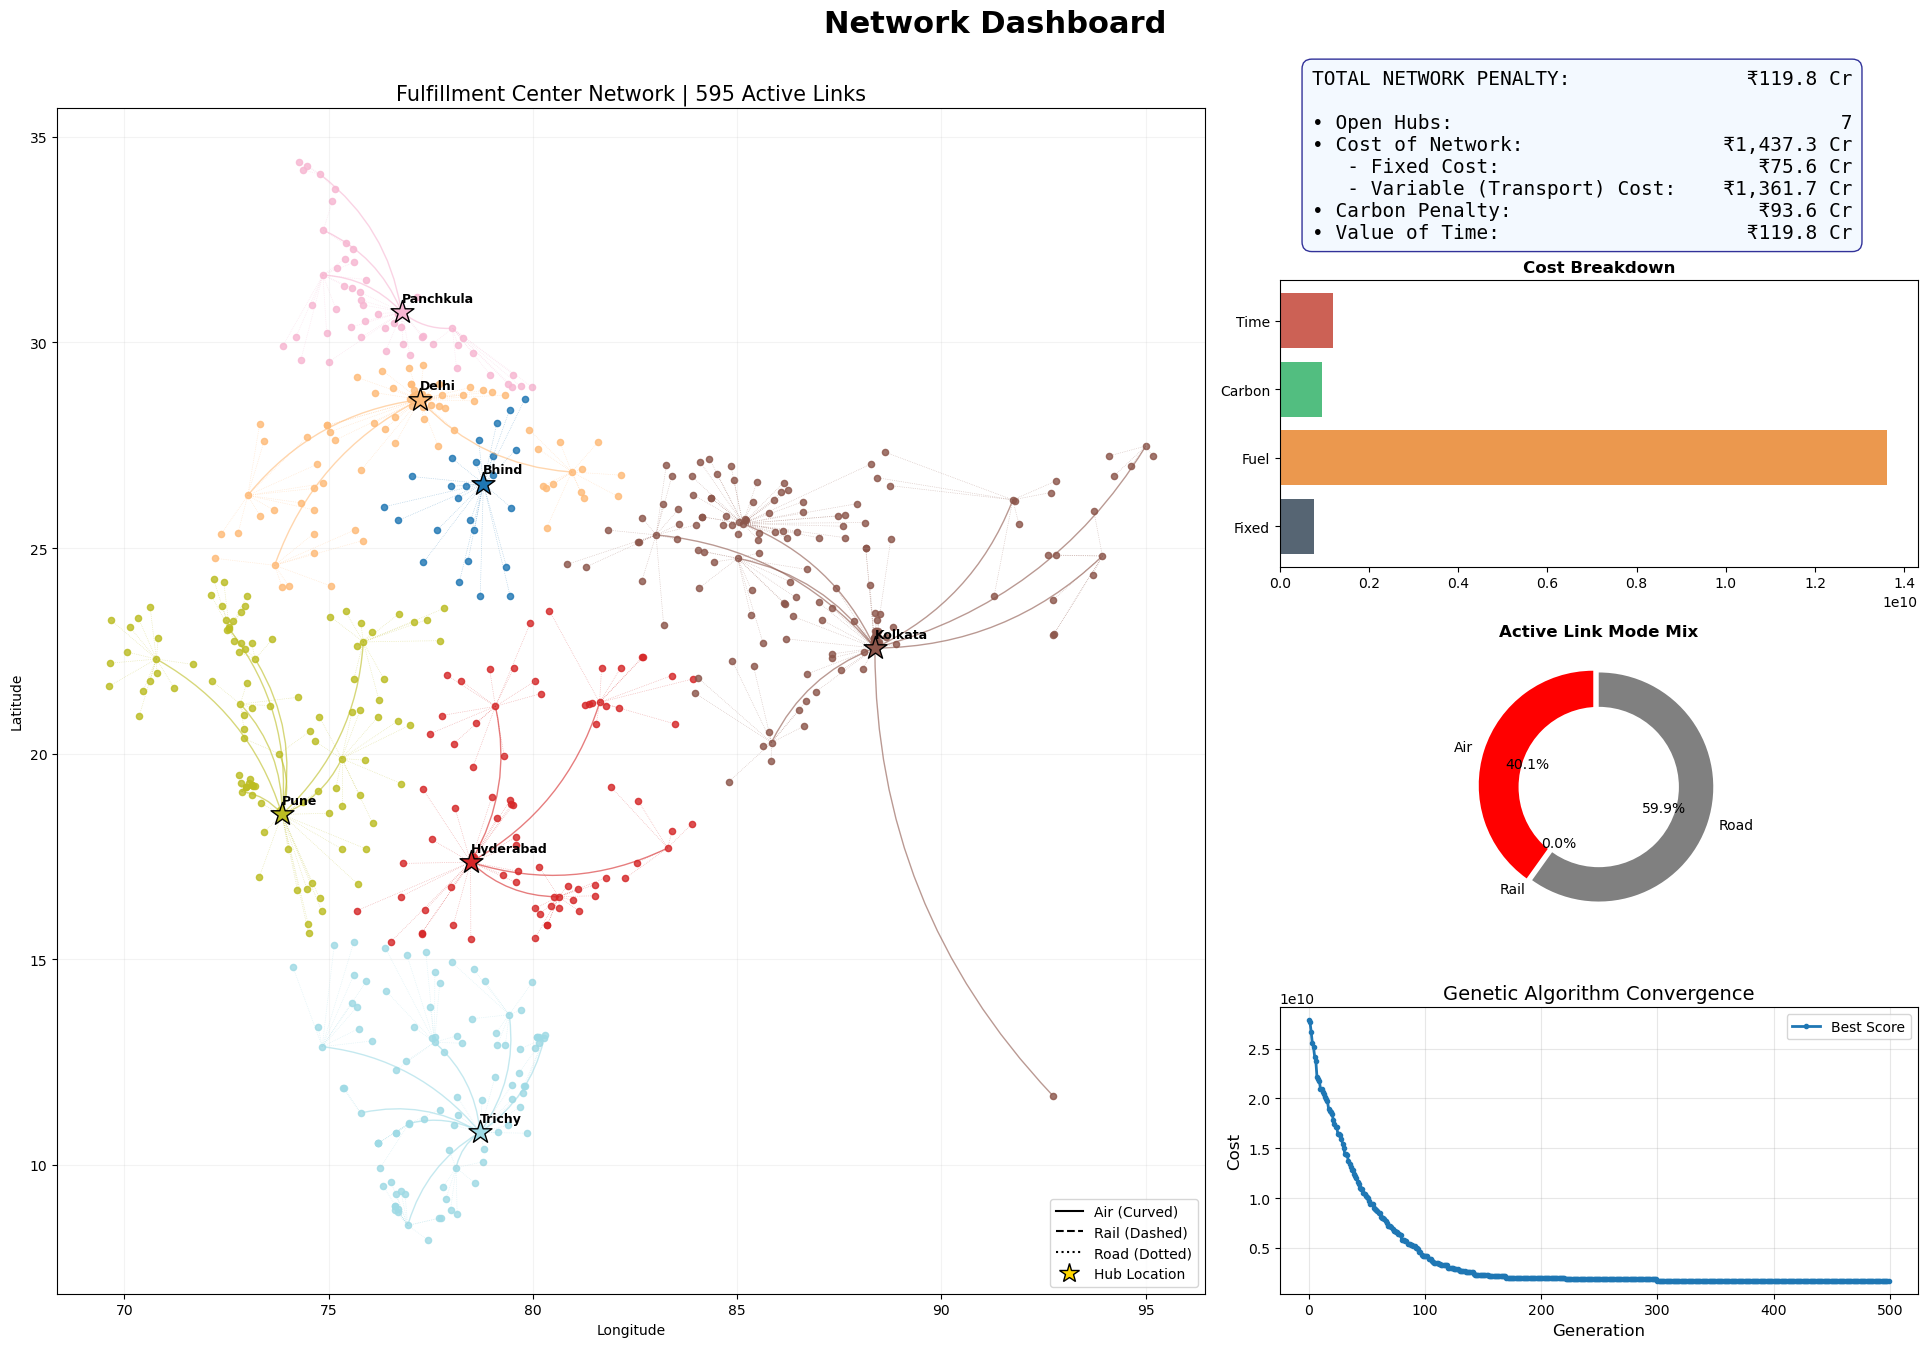

In [293]:
weights = {
    "fuel": 0,
    "carbon": 0,
    "time": 1,
}
transport_costs, cost_components, next_node = analyse_network(df, air_df, rail_df, weights)
ga = genetic_algorithm(generation_size = generation_size, 
                       reproduction_rate = reproduction_rate, 
                       mutation_rate_pop = mutation_rate_pop,
                       mutation_rate_bit = mutation_rate_bit,
                       num_generations = num_generations,
                       df = df,
                       fc_df = fc_df)
show_dashboard(df, ga, transport_costs, cost_components, next_node, fc_df, weights)

Step 1/4: Calculating physical distance matrix...


Step 3/4: Running Floyd Warshall algorithm...: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 602/602 [00:35<00:00, 16.85it/s]


Running genetic algorithm:
200 candidates in each generation
Each generation having binary values for 602 FCs


Step  4/4: Genetic algorithm...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [02:08<00:00,  3.88it/s]


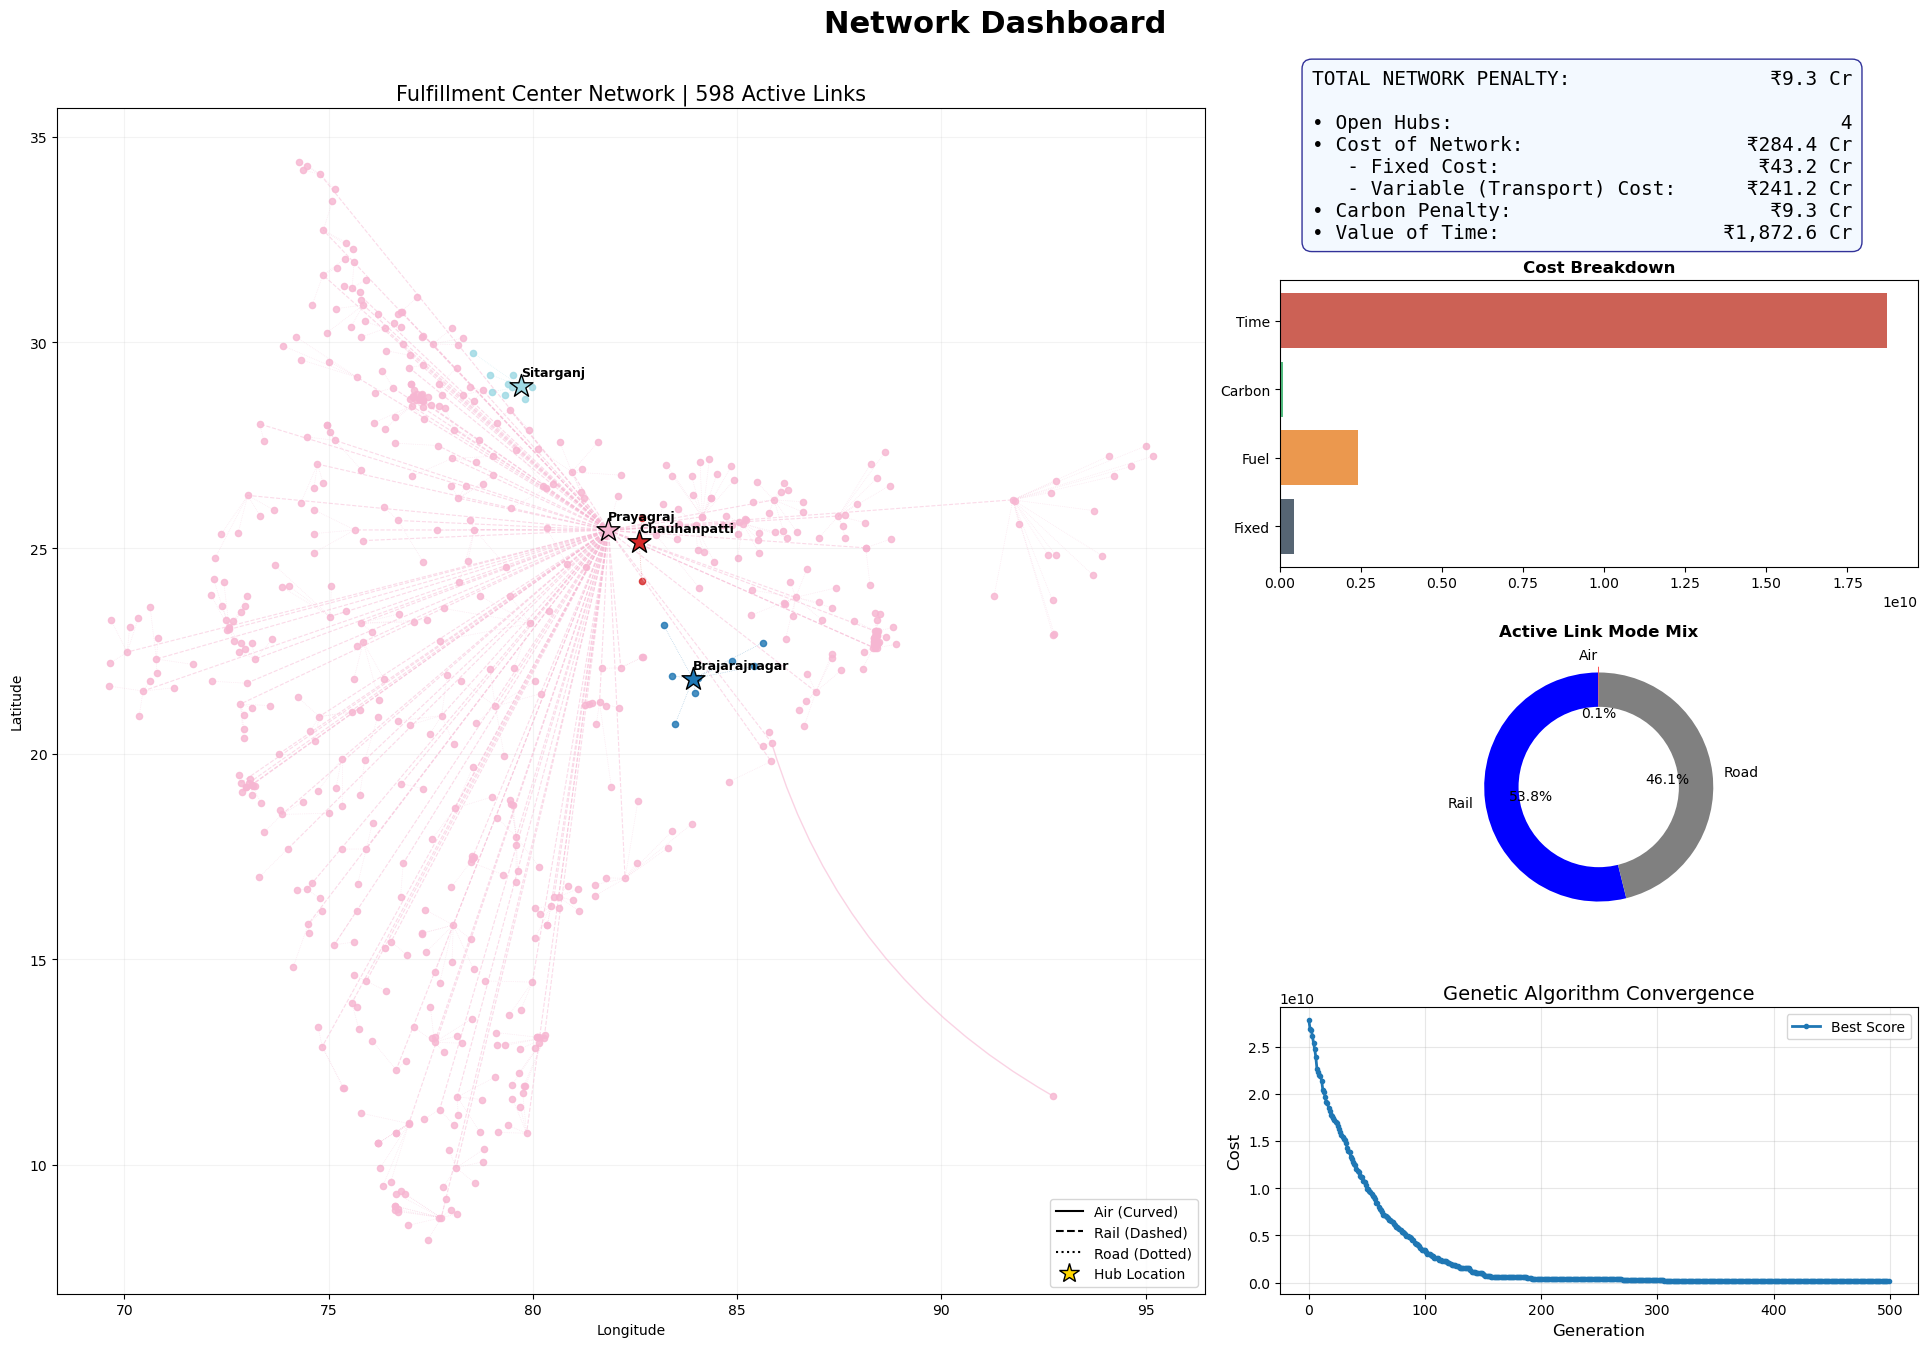

In [294]:
weights = {
    "fuel": 0,
    "carbon": 1,
    "time": 0,
}
transport_costs, cost_components, next_node = analyse_network(df, air_df, rail_df, weights)
ga = genetic_algorithm(generation_size = generation_size, 
                       reproduction_rate = reproduction_rate, 
                       mutation_rate_pop = mutation_rate_pop,
                       mutation_rate_bit = mutation_rate_bit,
                       num_generations = num_generations,
                       df = df,
                       fc_df = fc_df)
show_dashboard(df, ga, transport_costs, cost_components, next_node, fc_df, weights)

Step 1/4: Calculating physical distance matrix...


Step 3/4: Running Floyd Warshall algorithm...: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 602/602 [00:35<00:00, 16.90it/s]


Running genetic algorithm:
200 candidates in each generation
Each generation having binary values for 602 FCs


Step  4/4: Genetic algorithm...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [02:09<00:00,  3.88it/s]


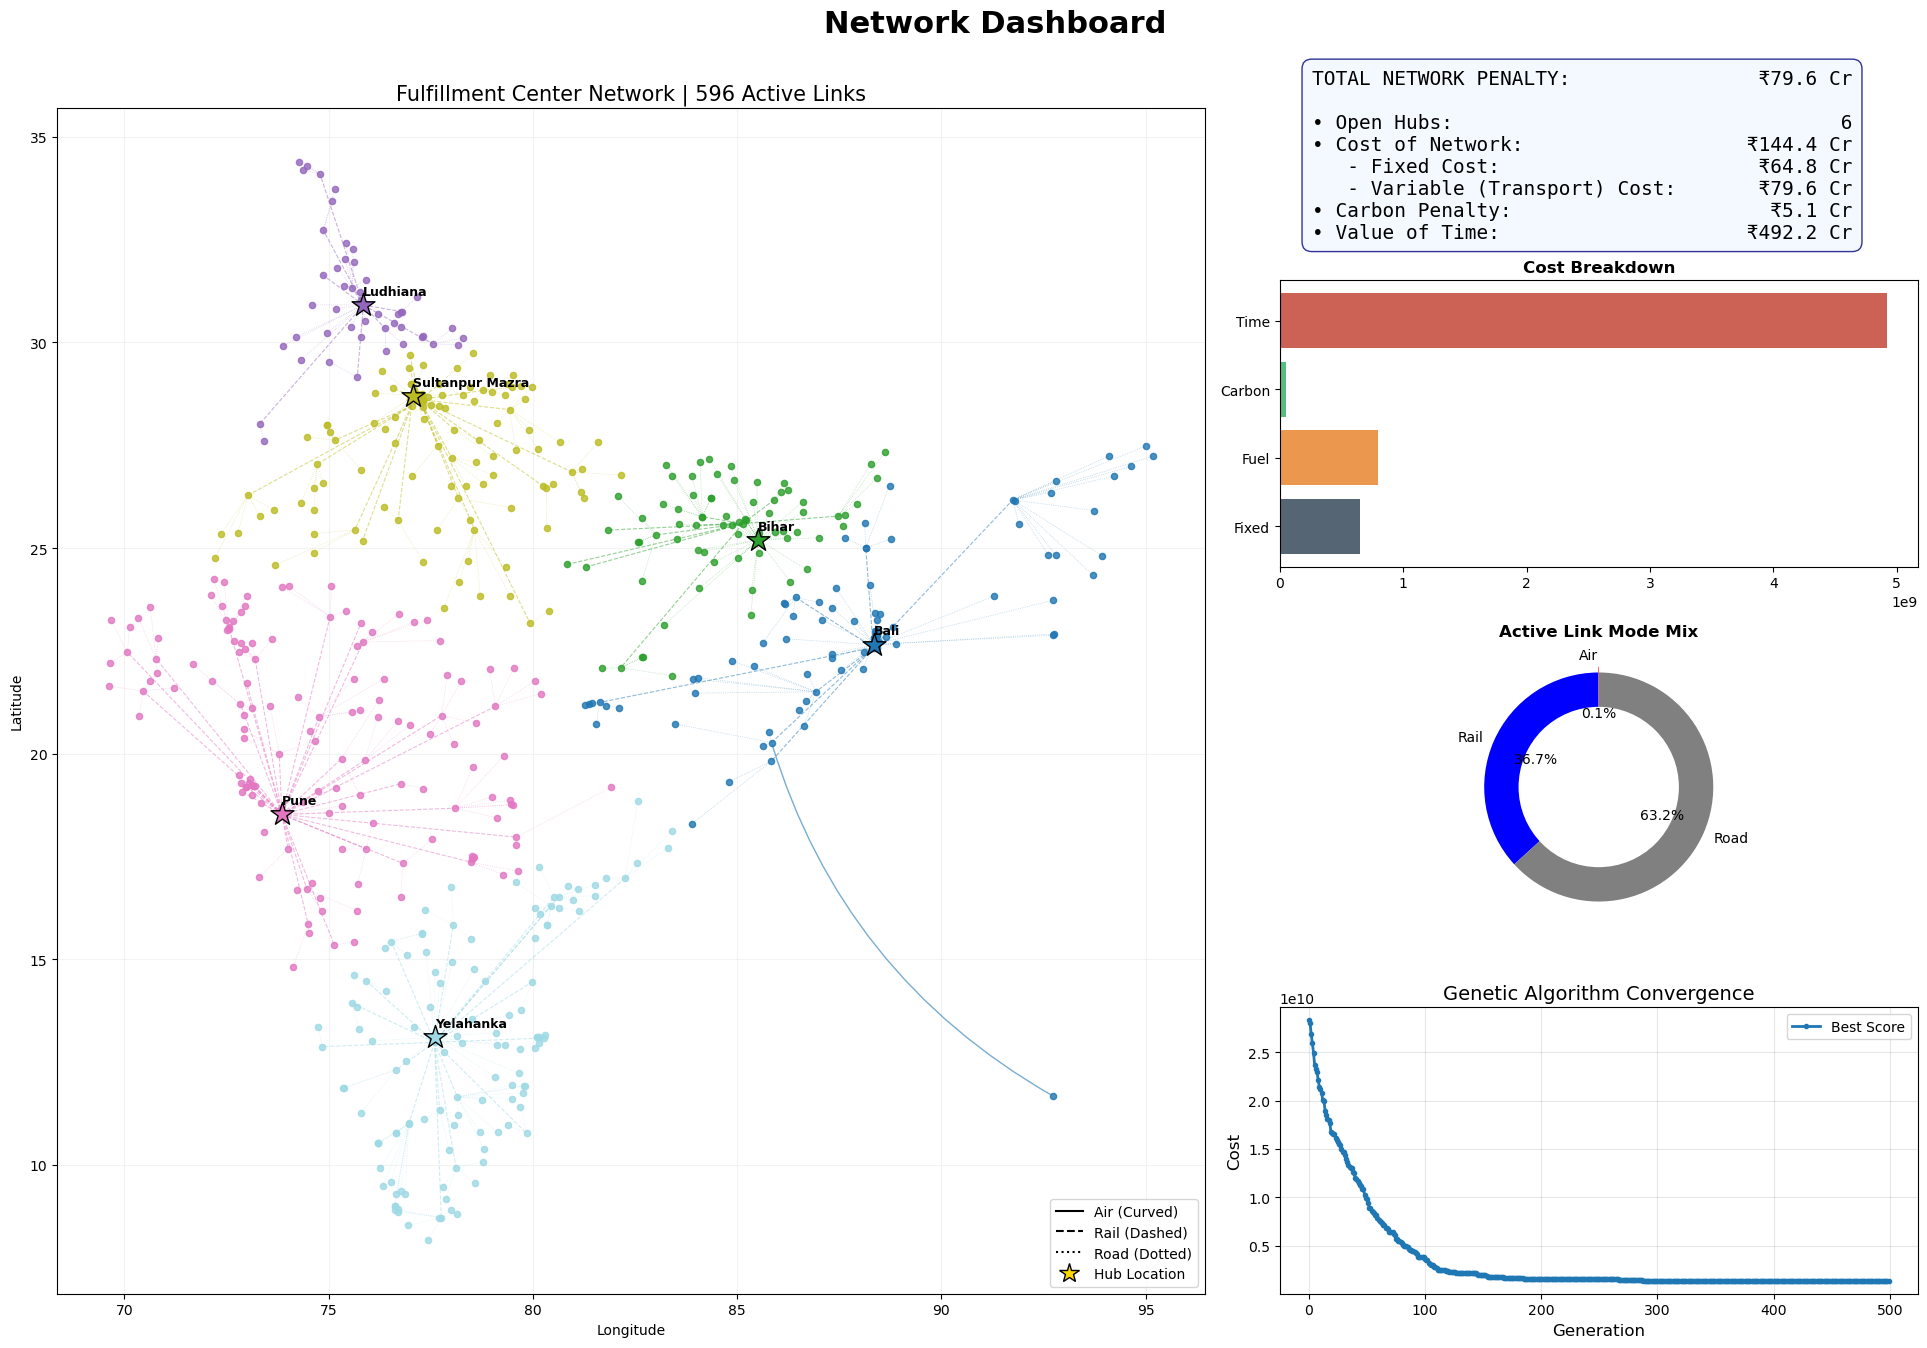

In [295]:
weights = {
    "fuel": 1,
    "carbon": 0,
    "time": 0,
}
transport_costs, cost_components, next_node = analyse_network(df, air_df, rail_df, weights)
ga = genetic_algorithm(generation_size = generation_size, 
                       reproduction_rate = reproduction_rate, 
                       mutation_rate_pop = mutation_rate_pop,
                       mutation_rate_bit = mutation_rate_bit,
                       num_generations = num_generations,
                       df = df,
                       fc_df = fc_df)
show_dashboard(df, ga, transport_costs, cost_components, next_node, fc_df, weights)

Step 1/4: Calculating physical distance matrix...


Step 3/4: Running Floyd Warshall algorithm...: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 602/602 [00:34<00:00, 17.26it/s]


Running genetic algorithm:
200 candidates in each generation
Each generation having binary values for 602 FCs


Step  4/4: Genetic algorithm...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [02:08<00:00,  3.88it/s]


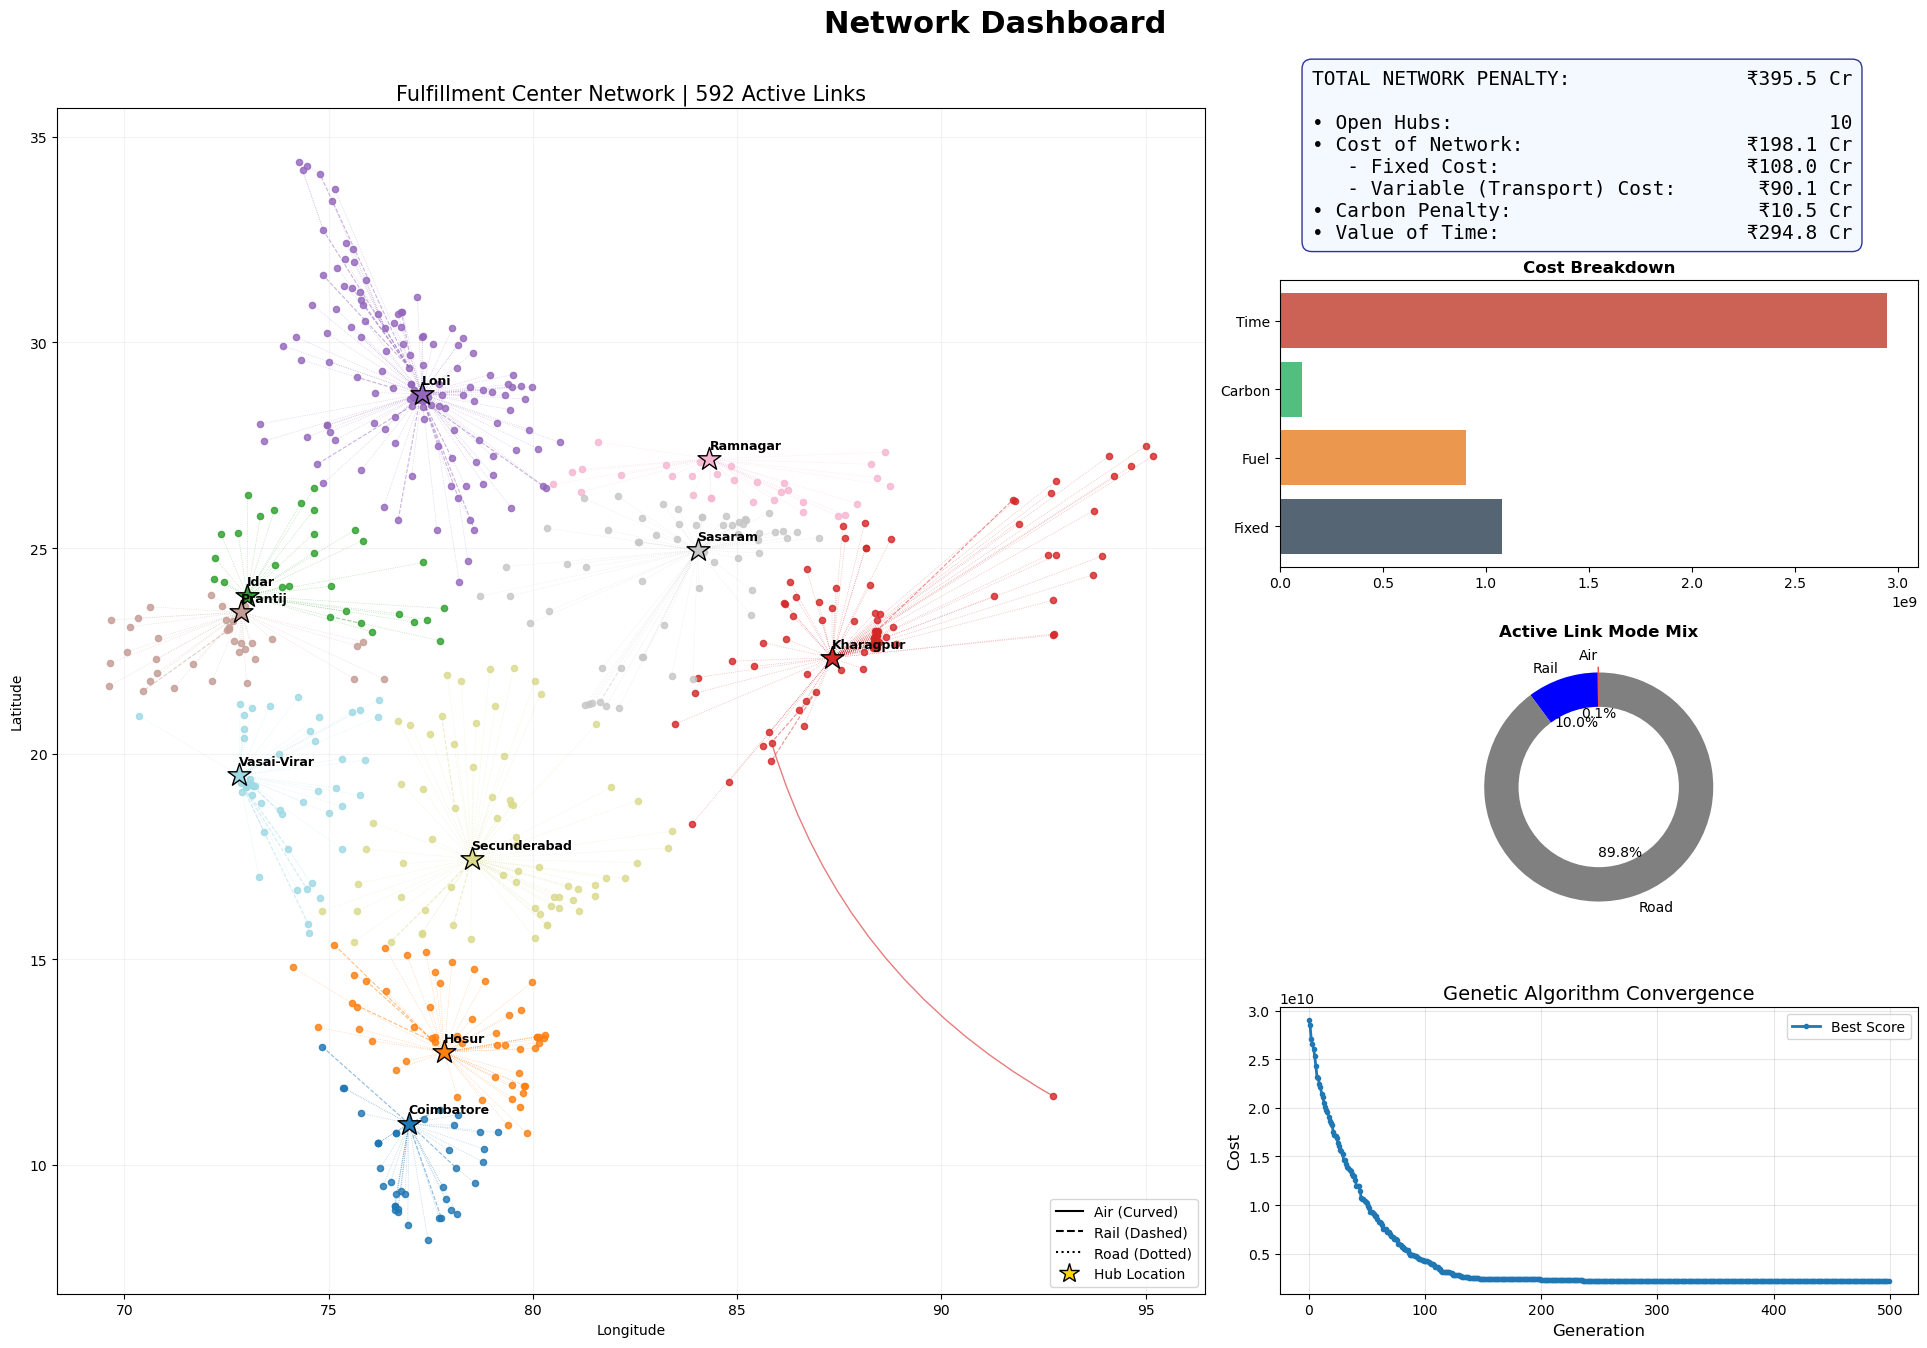

In [296]:
weights = {
    "fuel": 1,
    "carbon": 1,
    "time": 1,
}
transport_costs, cost_components, next_node = analyse_network(df, air_df, rail_df, weights)
ga = genetic_algorithm(generation_size = generation_size, 
                       reproduction_rate = reproduction_rate, 
                       mutation_rate_pop = mutation_rate_pop,
                       mutation_rate_bit = mutation_rate_bit,
                       num_generations = num_generations,
                       df = df,
                       fc_df = fc_df)
show_dashboard(df, ga, transport_costs, cost_components, next_node, fc_df, weights)